In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
from joblib import Parallel, delayed
from scipy.integrate import IntegrationWarning
from pthin import pthin, pcarve_ci, truncgauss_ci
import pickle

In [14]:
# Suppress integration warnings for clean console output
warnings.filterwarnings("ignore", category=IntegrationWarning)

## Filedrawer

In [15]:
def run_single_rep_filedrawer(mu, alpha, seed):
    """
    One replicate of the file-drawer CI comparison: unlike the winner's-curse
    setting below, each method has its own independent selection event (a
    single study is "significant at level alpha" or it isn't), so each
    method draws (rejecting non-significant studies) until it finds a
    selected one, then constructs its CI for that study. At alpha=0.05 this
    takes ~20-35 draws on average per method -- cheap relative to the CI
    construction itself.
    """
    rng = np.random.default_rng(seed)
    c_alpha = norm.isf(alpha)
    res = {"p-thinning": {}, "thinning": {}, "csi": {}}

    # --- 1. p-value thinning (Theorem) ---
    while True:
        X = rng.normal(mu, 1)
        p = norm.sf(X)
        p1, _ = pthin(p, epsilon=0.5, rng=rng)
        if p1 <= alpha:
            break
    try:
        mu_L, mu_U = pcarve_ci(
            X, 0.0, a=0.0, b=alpha, epsilon=0.5, alpha=alpha,
            input_type="statistic", epsabs=1e-4, epsrel=1e-4, limit=50,
        )
    except RuntimeError:
        mu_L, mu_U = X - 50, X + 50
    res["p-thinning"]["coverage"] = (mu_L <= mu <= mu_U)
    res["p-thinning"]["width"] = (mu_U - mu_L)

    # --- 2. Data thinning (Gaussian) ---
    while True:
        X = rng.normal(mu, 1)
        W = rng.normal(0, 1)
        X1 = (X + W) / np.sqrt(2)
        X2 = (X - W) / np.sqrt(2)
        if X1 >= c_alpha:
            break
    z_alpha = norm.isf(alpha / 2)
    dt_L = np.sqrt(2) * X2 - np.sqrt(2) * z_alpha
    dt_U = np.sqrt(2) * X2 + np.sqrt(2) * z_alpha
    res["thinning"]["coverage"] = (dt_L <= mu <= dt_U)
    res["thinning"]["width"] = (dt_U - dt_L)

    # --- 3. Conditional (Truncated Gaussian) ---
    while True:
        X = rng.normal(mu, 1)
        if X >= c_alpha:
            break
    try:
        cond_L, cond_U = truncgauss_ci(X, c=c_alpha, alpha=alpha)
    except RuntimeError:
        cond_L, cond_U = X - 50, X + 50
    res["csi"]["coverage"] = (cond_L <= mu <= cond_U)
    res["csi"]["width"] = (cond_U - cond_L)

    return res


def get_filedrawer_results(n_reps, mus, alpha, n_jobs=-1):
    """Parallelized evaluation using joblib, matching get_wc_results below."""
    results = {k: {"coverage": [], "width": []} for k in ["p-thinning", "thinning", "csi"]}

    ss = np.random.SeedSequence(7)
    child_seeds = ss.spawn(len(mus) * n_reps)

    seed_idx = 0
    for mu in mus:
        mu_seeds = child_seeds[seed_idx : seed_idx + n_reps]
        seed_idx += n_reps

        rep_results = Parallel(n_jobs=n_jobs)(
            delayed(run_single_rep_filedrawer)(mu, alpha, seed) for seed in mu_seeds
        )

        for k in results:
            results[k]["coverage"].append(np.mean([r[k]["coverage"] for r in rep_results]))
            results[k]["width"].append(np.mean([r[k]["width"] for r in rep_results]))

    return results

In [16]:
# --- Simulation Parameters ---
n_reps_fd = 1000
mus_fd = np.array([0, 1, 2, 3, 4])
alpha_fd = 0.05

filedrawer_results = get_filedrawer_results(n_reps_fd, mus_fd, alpha_fd)

In [17]:
with open("../results/filedrawer_ci.pkl", "wb") as f:
    pickle.dump(filedrawer_results, f)

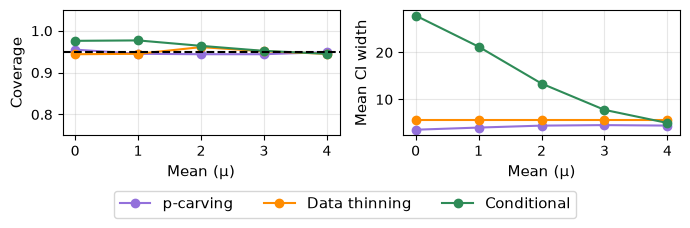

In [24]:
# --- Plotting ---
labels_fd = {
    "p-thinning": "p-carving",
    "thinning": "Data thinning",
    "csi": "Conditional",
}
colors_fd = {
    "p-thinning": "mediumpurple",
    "csi": "seagreen",
    "thinning": "darkorange",
}

fig, axes = plt.subplots(1, 2, figsize=(7, 2))

for k in filedrawer_results:
    axes[0].plot(mus_fd, filedrawer_results[k]["coverage"], marker="o", label=labels_fd[k], color=colors_fd[k])
axes[0].axhline(1 - alpha_fd, color="black", linestyle="--")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.75, 1.05)
axes[0].set_xlabel("Mean (μ)", fontsize=11)
axes[0].set_ylabel("Coverage", fontsize=11)

for k in filedrawer_results:
    axes[1].plot(mus_fd, filedrawer_results[k]["width"], marker="o", label=labels_fd[k], color=colors_fd[k])
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Mean (μ)", fontsize=11)
axes[1].set_ylabel("Mean CI width", fontsize=11)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0.06),
    ncol=3, frameon=True, fontsize=11,
)
plt.tight_layout()
plt.savefig("../figures/filedrawer_ci.png", dpi=300, bbox_inches="tight")
plt.show()

## Winner's curse

In [3]:
def run_single_rep(mu, gap_ratio, N_total, alpha, seed):
    """
    Executes a single replication of the simulation.
    Takes a unique SeedSequence child to guarantee independent random variables.
    """
    rng = np.random.default_rng(seed)
    
    # One-Sided Upper-Tailed Test
    X = rng.normal(0, 1, size=N_total)
    X[0] += mu
    X[1] += mu * gap_ratio
    p = norm.sf(X)

    res = {"p-thinning": {}, "thinning": {}, "csi": {}}

    # --- 1. p-value thinning (Theorem) ---
    p1, _ = pthin(p, epsilon=0.5, rng=rng)
    
    sel = np.argmin(p1)
    c_thin = np.sort(p1)[1]
    
    true_mu = mu if sel == 0 else (mu * gap_ratio if sel == 1 else 0.0)
    
    # a=0 selects the fast code path in pcarve_ci (matching the argmin(p1)
    # selection rule here: c_thin, the runner-up's p1, is the upper bound
    # of the selection interval [0, c_thin]). epsabs/epsrel/limit are set
    # loose to match this notebook's original calc_r_mu tolerances -- see
    # pcarve_ci's docstring.
    try:
        mu_L, mu_U = pcarve_ci(
            X[sel], 0.0, a=0.0, b=c_thin, epsilon=0.5, alpha=alpha,
            input_type="statistic", epsabs=1e-4, epsrel=1e-4, limit=50,
        )
    except RuntimeError:
        # Root-finding failed to bracket a root (rare); fall back to a wide
        # interval, matching the original safe_root's behavior here.
        mu_L, mu_U = X[sel] - 50, X[sel] + 50
    res["p-thinning"]["coverage"] = (mu_L <= true_mu <= mu_U)
    res["p-thinning"]["width"] = (mu_U - mu_L)

    # --- 2. Data thinning (Gaussian) ---
    eps = rng.normal(0, 1, size=N_total)
    X1 = (X + eps) / np.sqrt(2)
    X2 = (X - eps) / np.sqrt(2)
    
    sel_dt = np.argmax(X1)
    true_mu_dt = mu if sel_dt == 0 else (mu * gap_ratio if sel_dt == 1 else 0.0)
    
    X2_sel = X2[sel_dt]
    z_alpha = norm.isf(alpha / 2)
    dt_L = np.sqrt(2) * X2_sel - np.sqrt(2) * z_alpha
    dt_U = np.sqrt(2) * X2_sel + np.sqrt(2) * z_alpha
    
    res["thinning"]["coverage"] = (dt_L <= true_mu_dt <= dt_U)
    res["thinning"]["width"] = (dt_U - dt_L)

    # --- 3. Conditional (Truncated Gaussian) ---
    sel_cond = np.argmax(X)
    true_mu_cond = mu if sel_cond == 0 else (mu * gap_ratio if sel_cond == 1 else 0.0)
    
    c_cond = np.sort(X)[-2]
    
    try:
        cond_L, cond_U = truncgauss_ci(X[sel_cond], c=c_cond, alpha=alpha)
    except RuntimeError:
        cond_L, cond_U = X[sel_cond] - 50, X[sel_cond] + 50
    res["csi"]["coverage"] = (cond_L <= true_mu_cond <= cond_U)
    res["csi"]["width"] = (cond_U - cond_L)

    return res

def get_wc_results(N_total, n_reps, mus, gap_ratio, alpha, n_jobs=-1):
    """
    Parallelized evaluation using joblib.
    n_jobs=-1 will use all available CPU cores.
    """
    results = {
        k: {"coverage": [], "width": []}
        for k in ["p-thinning", "thinning", "csi"]
    }
    
    # Properly seed the parallel PRNGs to avoid duplicate random numbers
    ss = np.random.SeedSequence(42)
    
    # Spawn enough independent seeds for every single rep across all mu's
    child_seeds = ss.spawn(len(mus) * n_reps)

    seed_idx = 0
    for mu in mus:
        # Get the slice of seeds for the current mu
        mu_seeds = child_seeds[seed_idx : seed_idx + n_reps]
        seed_idx += n_reps
        
        # Parallelize across the `n_reps` replications
        rep_results = Parallel(n_jobs=n_jobs)(
            delayed(run_single_rep)(mu, gap_ratio, N_total, alpha, seed)
            for seed in mu_seeds
        )
        
        # Aggregate the results from the parallel jobs
        for k in results:
            mean_cov = np.mean([r[k]["coverage"] for r in rep_results])
            mean_width = np.median([r[k]["width"] for r in rep_results])
            results[k]["coverage"].append(mean_cov)
            results[k]["width"].append(mean_width)

    return results

In [8]:
# --- Simulation Parameters ---
# (n_reps can be reduced if you want to test the script execution time quickly)
n_reps = 1000
n_total = 10
mus = np.linspace(0, 4, 5)
alpha = 0.05

In [ ]:
results_low = get_wc_results(n_total, n_reps, mus, 0, alpha)
results_med = get_wc_results(n_total, n_reps, mus, 0.5, alpha)
results_high = get_wc_results(n_total, n_reps, mus, 1, alpha)

/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/7

In [ ]:
filename = "../results/winners_ci.pkl"
with open(filename, "wb") as f:
    pickle.dump(
        {
            "low": results_low,
            "med": results_med,
            "high": results_high
        }, f)

In [6]:
with open("../results/winners_ci.pkl", 'rb') as f:
    data_df = pickle.load(f)
results_low = data_df['low']
results_med = data_df['med']
results_high = data_df['high']

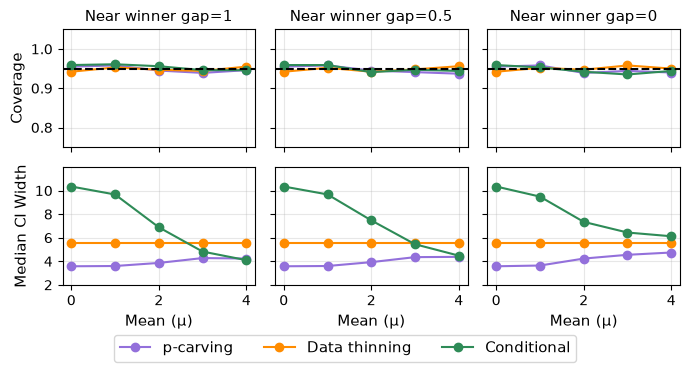

In [12]:
# --- Plotting ---
labels = {
    'p-thinning': 'p-carving',
    'thinning': 'Data thinning',
    'csi': 'Conditional'
}
colors = {
    'p-thinning': 'mediumpurple', #  'steelblue', actually p-carving
    'csi': 'seagreen',
    'thinning': 'darkorange'
}

fig, axes = plt.subplots(2, 3, figsize=(7, 3.5), sharex=True, sharey='row')

# Loop over the 3 gap ratio scenarios
for i, results, n in zip([0, 1, 2], [results_low, results_med, results_high], [0, 0.5, 1]):
    
    # 1. Plot Coverage
    for k in results:
        axes[0, i].plot(mus, results[k]['coverage'], marker='o', label=labels[k], color=colors[k]) 
    
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axhline(1 - alpha, color='black', linestyle='--')
    axes[0, i].set_title(f'Near winner gap={1 - n}', fontsize=11)
    axes[0, i].set_ylim(0.75, 1.05)
    
    # 2. Plot CI Width
    for k in results:
        axes[1, i].plot(mus, results[k]['width'], marker='o', label=labels[k], color=colors[k])   
        
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlabel('Mean (μ)', fontsize=11)
    axes[1, i].set_ylim(2, 12)  # Cut off infinite explosion for CSI visualization

axes[0, 0].set_ylabel('Coverage', fontsize=11)
axes[1, 0].set_ylabel('Median CI Width', fontsize=11)
axes[1, 0].set_yticks([2, 4, 6, 8, 10])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.17)
plt.savefig('../figures/winners_ci.png', dpi=300, bbox_inches='tight')
plt.show()
